# 2D dynamical system in 3D

## Setup

### Packages and functions

In [16]:
using LinearAlgebra, GLMakie, NLsolve
using StatsBase: mean, sample, wsample, median
import Random

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa, SurfaceFun.sphere

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

ax3d(f;azymuth=0.4pi,kwargs...) = # 0.7pi or 0.4pi
    Axis3(
        f, viewmode=:fitzoom, aspect=:data, azimuth=azymuth,
        xlabel=varnames[1], ylabel=varnames[2], zlabel=varnames[3],
        protrusions=(30,0,30,0)
    )

ax3d (generic function with 1 method)

### Makie theme

In [25]:
if false
    # for figure: white BG, vector graphics
    import CairoMakie
    CairoMakie.activate!(type="svg")
    linecolor = :black
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use: dark BG, raster graphics
    using GLMakie
    GLMakie.activate!(px_per_unit=1)
    linecolor = :black
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Model definition

In [26]:
shape = SetShape(:quadric)
J, G, Dc, divM, curlM = diffOpsM(shape.f) #;drgi=drgi)
rtgi(x,y) = G(x,y)^(-1/2)
U(x,y) = exp(-((x+1/2)^2+(y+1/2)^2)/2) - exp(-((x-1/2)^2+(y-1/2)^2)/2)
fg(x,y) = -∇(U)(x,y) # gradient part
fc(x,y) = [0,0] #Q*fg(x,y) # curl part for sphere: J*g^-1*F = du
fp(x,y) = fg(x,y) + fc(x,y) # vector field on parameter space

# Velocity on parameter space for simulation
vfp(x) = G(x...)\fp(x...) # inverse-scaled vector field
# Velocity on tangent plane for observation
vft(x) = J(x...)*vfp(x) # (J √g⁻¹)'(J √g⁻¹) = I

# Vector calculus on M
divRM = divM(fp)
curlRM = curlM(fp)

fps = sort([nlsolve(spa(fp),x).zero for x in [[0.5,0.5],[-0.5,-0.5]]])

2-element Vector{Vector{Float64}}:
 [-0.7717023191948433, -0.7717023191948433]
 [0.7717023191948433, 0.7717023191948433]

## Sampling trajectory

In [27]:
N = 1600
μc = fps[argmin(first.(fps))]
samples = let tmax = 100 #[-1.0,0.5] #[-0.5,-0.5] #fps[argmin(first.(fps))]
    samples = zeros(2,tmax+1,N)
    gbase = rtgi(μc...)
    @time for i in 1:N
        ini = 0.5*gbase*randn(2) + μc
        samples[:,:,i] = kutta(vfp,ini,dt=0.02,s=tmax)
    end
    samples
end

  3.992143 seconds (41.47 M allocations: 1.596 GiB, 7.48% gc time)


2×101×1600 Array{Float64, 3}:
[:, :, 1] =
 -0.151137  -0.146025  -0.140912  …   0.308797   0.3128    0.316787
 -1.58344   -1.58822   -1.59297      -1.92255   -1.92479  -1.92701

[:, :, 2] =
 -0.882841   -0.880581   -0.878182   …  0.0556989  0.0667321  0.0776409
 -0.0467681  -0.0355148  -0.0241419     0.884553   0.886571   0.888461

[:, :, 3] =
 -1.16746  -1.17028  -1.17309  -1.17589  …  -1.39468  -1.39648  -1.39826
 -1.41644  -1.42107  -1.42568  -1.43029     -1.804    -1.80719  -1.81036

;;; … 

[:, :, 1598] =
 -0.639795  -0.636538  -0.633191  -0.629752  …  0.365518  0.374837  0.383925
 -0.57386   -0.569607  -0.56525   -0.560786     0.47044   0.478391  0.486116

[:, :, 1599] =
 -0.72323   -0.722734  -0.722233  …  -0.640396  -0.639077  -0.637747
 -0.953163  -0.955852  -0.958575     -1.39463   -1.40061   -1.40661

[:, :, 1600] =
 -0.668163  -0.664763  -0.661249  -0.657617  …  0.360379  0.368829  0.37709
 -0.449975  -0.443381  -0.436637  -0.429738     0.619082  0.62397   0.628698

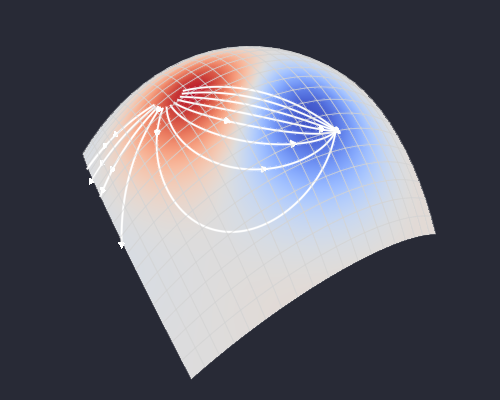

In [28]:
#pts2 = Point2f.(eachcol(samples[:,50,:]))
pts2 = [Point2f(sample(eachcol(samples[:,:,i]))) for i in 1:size(samples,3)] # random time
#pts2 = vec(let xs=LinRange(-2,2,40); ((x,y) -> Point2f(x,y)).(xs',xs);end) # grid

pts2 = vcat(Point2f.(fps),pts2); N=1600+length(fps) # add fixed points 
X = hcat(spa(shape.f).(pts2)...)
pts = Point3f.(eachcol(X))
V = hcat(vft.(pts2)...)
#zshift(p;s=0.01) = p + Point3f(0,0,s)

fig=Figure(size=(500,400))
ax = LScene(fig[1,1],show_axis=false)
rx = 2.1
xs = LinRange(-rx,rx,20)
P = Point3f.(shape.f.(xs,xs'))
#vfun = x -> G(x...)\ff(x...)
#scatter!(ax,pts,markersize=5,color=:lightgrey,transparency=false)
#surface!(ax,xs,xs,last.(P).-0.02,color=U.(xs,xs'),transparency=false,shading=NoShading)
surface!(ax,xs,xs,last.(P).-0.02,color=divRM.(xs,xs'),colormap=:coolwarm,transparency=false,shading=NoShading)
#surface!(ax,xs,xs,last.(P).-0.02,colormap=[RGBf([8,31,92]/255...)],transparency=false,shading=NoShading)
wireframe!(ax,xs,xs,last.(P).-0.01,color=:lightgrey,transparency=true,linewidth=0.5)

#for ϕ in LinRange(-pi,pi,12)[2:end], dir in [-1,1], θ in [0,pi/2]
for ini in [μc+0.2*[cos(θ),sin(θ)] for θ in LinRange(-1.8,1,12)]
    traj = kutta(normalize ∘ vfp,ini,dt=0.05,s=80)
    traj3 = Point3f.(spa(shape.f).(eachcol(traj)))
    oor = findfirst([abs(x)>rx || abs(y)>rx for (x,y,z) in traj3])
    if !isnothing(oor)
        traj3 = traj3[1:oor]
    end
    lines!(ax,traj3,color=:white,transparency=true,linewidth=2)
    ishow = sample(1:length(traj3),2)
    #scatter!(ax,traj3[ishow])
    tvs = Vec3f.(vft.(eachcol(traj[:,ishow])))
    quiver!(    
        ax, traj3[ishow], 0.01tvs,
        arrowsize=0.09, linewidth=0.015, color=:white, #RGBf([8,31,92]/255...),
        shading=NoShading,transparency=true
    )
end

#ishow = sample(1:N,100)
#quiver!(ax,vec(P),vec(0.2*vps),color=:black,fxaa=true,arrowsize=0.06,linewidth=0.015,shading=MultiLightShading,transparency=false)
# quiver!(    
#     ax, pts[ishow], 0.4*Vec3f.(eachcol(V)[ishow]),
#     arrowsize=0.06, linewidth=0.015, color=:white, #RGBf([8,31,92]/255...),
#     shading=NoShading,transparency=true
# )

cam3d!(ax.scene, center=false)
translate!(ax.scene,Vec3f(0,0,2.5))
eyepos = Vec3f(sphere(-30pi/180,60pi/180,r=7.5))
update_cam!(ax.scene, eyepos, Vec3f(0), Vec3f(0,0,1))
fig

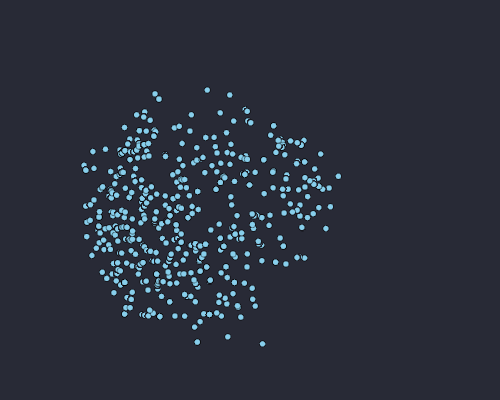

In [29]:
fig=Figure(size=(500,400))
ax = LScene(fig[1,1],show_axis=false)
ishow = sample(1:N,500)
#quiver(pts2[ishow],Vec2f.(eachcol(0.2V[:,ishow])))
#scatter!(ax,pts[ishow],color=RGBf([8,31,92]/255...),markersize=8,strokewidth=0.5,strokecolor=:white)
scatter!(ax,pts[ishow],color=:skyblue,markersize=8,strokewidth=0.5,strokecolor=:black)
cam3d!(ax.scene, center=false)
translate!(ax.scene,Vec3f(0,0,2.5))
eyepos = Vec3f(sphere(-60pi/180,90pi/180,r=7.5))
update_cam!(ax.scene, eyepos, Vec3f(0), Vec3f(0,0,1))
fig

## Embedding

In [30]:
# Epanechnikov quadratic kernel
kernel(t) = 3/4*(1-t^2) # defined for 0<=t<=1
#kernel(t;σ=1) = gauss(t,μ=0,σ=0.5)

# K-nn value
function knnvalue(x;tree,value,k=30,ϵ=0.5)
    i, d = knn(tree, x, k, true)
    (d[1] > ϵ) && return(fill(NaN,length(value[1])))
    v = value[i]
    w = kernel.(d/d[k])
    v'*(w/sum(w))
end

knnvf(x;k=10,ϵ=0.5,vels,tree) = vec(knnvalue(x;tree=tree,value=vels,k=k,ϵ=ϵ))

function stream!(ax,X,V;k=10,ϵ=0.1,opts...)
    d = size(X,1)
    vf = x -> knnvf(x;tree=KDTree(X),vels=eachcol(V),k=k,ϵ=ϵ)
    interval = x -> minimum(1.1x)..maximum(1.1x)
    exts = interval.(eachrow(X))
    streamplot!(
        ax, Point{d,Float32} ∘ vf, exts...;
        colormap=[:black],arrow_size=8,linewidth=1.5,
        gridsize=Tuple(fill(20,d)),
        opts...
    ) 
    #arrow_size=arrow_size,linewidth=1.8,colormap=[(color,0.6)],gridsize=gridsize)
end

# Velocity embedding; according to scvelo method
function vemb(g,Xe,X,V;σ=1.0)
    map(1:nv(g)) do i
        neis = neighbors(g,i)
        # normalized displacement in the embedding space
        D = mapslices(normalize,X[:,neis] .- X[:,i],dims=1)
        De = mapslices(normalize,Xe[:,neis] .- Xe[:,i],dims=1)
        # cosine weights
        wts = exp.(D'*normalize(V[:,i])/σ^2)
        # density correction
        De*(wts/sum(wts) .- 1/length(wts))
    end
end

# Show as directional field
function dirfld!(ax,xs,vs;α=1.0,color=nothing,cmap=:coolwarm,opts...)
    d = size(xs,1)
    xs = Point{d,Float32}.(eachcol(xs))
    vs = α*Vec{d,Float32}.(normalize.(eachcol(vs)))
    cmax = clipmax(color,p=0.99)
    quiver!(
        ax, xs.-0.5vs, vs;
        color=color, arrowsize=0, linewidth=1,
        colormap=cmap, colorrange=(-cmax,cmax),
        opts...
    )
end

mark12!(ax,X;opts...) = scatter!(
    ax, Point2f.(eachcol(X[1:2,1:2]));
    strokewidth=2, strokecolor=[:salmon,:skyblue],
    markersize=8, color=[:salmon,:skyblue], #:transparent, 
    opts...
)

mark12! (generic function with 1 method)

In [31]:
using ddHodge, Graphs
import UMAP
umodel = UMAP.UMAP_(X,min_dist=0.5,n_epochs=500)
UM = umodel.embedding
divana = spa(divRM).(pts2)
g, kdtree = kNNGraph(X,6)
#import TSne
#Ut = TSne.tsne(X')'

(SimpleGraph{Int64}(5732, [[99, 489, 532, 1501, 1582, 1599], [96, 253, 353, 1288, 1419, 1576], [130, 240, 306, 378, 509, 518, 828, 851, 1122, 1425], [384, 591, 629, 706, 794, 849, 950, 1182, 1558], [299, 374, 470, 637, 822, 1200, 1342], [44, 575, 1066, 1164, 1354, 1598], [51, 301, 598, 691, 833, 925, 1311, 1546], [288, 572, 673, 999, 1024, 1326, 1446], [571, 599, 602, 866, 949, 955, 1079, 1224], [24, 193, 222, 273, 412, 601, 1545]  …  [476, 835, 956, 968, 1110, 1396], [62, 287, 328, 520, 658, 704, 1118], [186, 930, 1165, 1460, 1494, 1540], [409, 666, 935, 1347, 1442, 1448], [285, 395, 468, 551, 1494, 1512, 1540], [6, 44, 575, 995, 1066, 1164, 1354], [1, 99, 489, 532, 756, 1044, 1501], [145, 488, 854, 1000, 1368, 1440], [89, 106, 156, 298, 362, 860, 1451], [474, 808, 967, 1116, 1380, 1468]]), NearestNeighbors.KDTree{StaticArraysCore.SVector{3, Float64}, Distances.Euclidean, Float64, StaticArraysCore.SVector{3, Float64}}
  Number of points: 1602
  Dimensions: 3
  Metric: Distances.Euclid

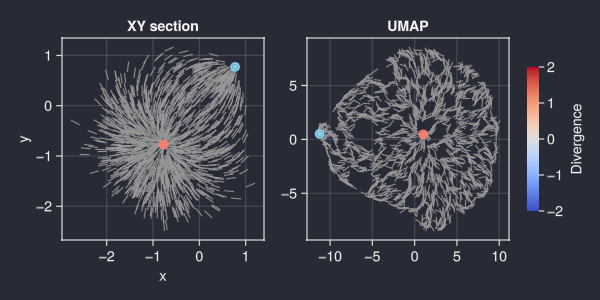

In [32]:
Vu = hcat(vemb(g,UM,X,V,σ=1.0)...)
#Vt = hcat(vemb(g,Ut,X,V,σ=1.0)...)
#Vc = hcat(spa(devcone).(pts2 + vfp.(pts2)) - eachcol(UC)...)

let showstream=false, cmap=:coolwarm #[:grey]
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=1,title="XY section",xlabel="x",ylabel="y")
    ax2 = Axis(fig[1,2],aspect=1,title="UMAP")
    dirfld!(ax1,X[1:2,:],V[1:2,:]; α=0.2,color=divana, cmap=[:grey60])
    showstream && stream!(ax1,X[1:2,:],V[1:2,:],ϵ=0.2)#,ϵ=1.0)
    mark12!(ax1,X[1:2,:])
    dirfld!(ax2,UM,Vu;α=0.8,cmap=[:grey60], color=divana)
    showstream && stream!(ax3,UM,Vu,arrow_size=8,ϵ=2.0)#10.0)
    mark12!(ax2,UM)
    Colorbar(fig[1,3],colormap=:coolwarm,colorrange=(-2,2),height=Relative(0.7),label="Divergence")
    fig
end